# 图像特征练习  
*请完成并提交这份完整的练习表（包括所有输出结果以及表格外部的支撑代码），与本次作业一并上传。更多细节请参见课程官网的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

在前面的实验中，我们已经看到，直接在输入图像的原始像素上训练线性分类器，可以在图像分类任务上取得尚可的表现。  
在本练习中，我们将证明：如果不再使用原始像素，而是使用从原始像素**计算得到的特征**来训练线性分类器，可以进一步提升分类性能。

本练习的所有工作都将在本 notebook 内完成。

In [4]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# 让 Matplotlib 在 notebook 内直接显示图片
%matplotlib inline
# 统一设置图片默认尺寸，方便查看
plt.rcParams['figure.figsize'] = (10.0, 8.0)
# 关闭插值，使像素边界更清晰
plt.rcParams['image.interpolation'] = 'nearest'
# 灰度图默认使用灰度色图
plt.rcParams['image.cmap'] = 'gray'

# 开启 IPython 的自动重载功能：当外部 .py 文件被修改后，无需重启 kernel 即可立即生效
# 官方文档/讨论贴：http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# 注：由于网络原因，上述链接解析失败。如果你需要查看具体内容，请自行检查链接是否有效或稍后重试。
%load_ext autoreload
%autoreload 2

## 加载数据
与之前的练习一样，我们将从磁盘加载 CIFAR-10 数据集。

In [5]:
# 从 cs231n.features 导入两种常用图像特征提取函数：
# - color_histogram_hsv：将图像转成 HSV 空间后统计颜色直方图
# - hog_feature：计算 HOG（方向梯度直方图）特征
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    """
    加载并划分 CIFAR-10 数据集。

    参数
    ----
    num_training : int
        训练集样本数（默认 49000）
    num_validation : int
        验证集样本数（默认 1000）
    num_test : int
        测试集样本数（默认 1000）

    返回
    ----
    X_train, y_train, X_val, y_val, X_test, y_test : ndarray
        划分好的训练/验证/测试图像及对应标签
    """

    # CIFAR-10 二进制文件所在目录
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # 如果之前已经加载过数据，先手动清理变量，防止重复加载导致内存占用过高
    try:
        del X_train, y_train
        del X_test, y_test
        print('已清空之前加载的数据。')
    except:
        pass

    # 真正从磁盘读取 CIFAR-10 数据
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # 从训练集中划分出验证集
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]

    # 截取指定数量的训练样本
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]

    # 截取指定数量的测试样本
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

# 调用函数，获得划分好的数据
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## 提取特征
对于每张图像，我们将计算两种特征：
1. **HOG（方向梯度直方图，Histogram of Oriented Gradients）**
2. **HSV 颜色空间中 Hue 通道的颜色直方图**

随后，我们把这两种特征向量**拼接（concatenate）**在一起，作为该图像最终的特征向量。

简单而言：
- HOG 主要捕捉图像的**纹理信息**，同时忽略颜色；
- 颜色直方图则主要反映图像的**颜色分布**，同时忽略纹理。

因此，将二者结合使用，通常会比单独使用其中任何一种效果更好。你可以利用这一点做进一步的实验验证。

`hog_feature` 和 `color_histogram_hsv` 两个函数都针对**单张图像**计算并返回对应的特征向量。  
`extract_features` 函数接收一组图像和一组特征函数，依次在每个图像上调用这些特征函数，并把结果按列拼接成一个矩阵：矩阵的每一列就是单张图像经过所有特征函数后得到的完整特征向量。

In [6]:
# 从 cs231n.features 中导入所有自定义特征提取工具
from cs231n.features import *

# 设置颜色直方图的桶数（bin 个数）
num_color_bins = 25

# 定义要提取的特征函数列表：
# 1. hog_feature：计算 HOG（方向梯度直方图）特征
# 2. lambda img: color_histogram_hsv(img, nbin=num_color_bins)
#    用匿名函数包装 color_histogram_hsv，指定桶数为 num_color_bins
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]

# 依次对训练、验证、测试集提取上述两类特征
# extract_features 会把每张图像得到的所有特征向量拼接成一行
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats   = extract_features(X_val,   feature_fns)
X_test_feats  = extract_features(X_test,  feature_fns)

# ---------------- 特征预处理 ----------------
# 1. 去均值：用训练集特征的均值对所有集合作中心化
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats   -= mean_feat
X_test_feats  -= mean_feat

# 2. 标准化：除以训练集特征的标准差，使每个特征维度尺度大致相同
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats   /= std_feat
X_test_feats  /= std_feat

# 3. 添加偏置维度（bias term）：在特征矩阵最右侧拼接一列全 1
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats   = np.hstack([X_val_feats,   np.ones((X_val_feats.shape[0], 1))])
X_test_feats  = np.hstack([X_test_feats,  np.ones((X_test_feats.shape[0], 1))])

已完成 1000 / 49000 张图像的特征提取
已完成 2000 / 49000 张图像的特征提取
已完成 3000 / 49000 张图像的特征提取
已完成 4000 / 49000 张图像的特征提取
已完成 5000 / 49000 张图像的特征提取
已完成 6000 / 49000 张图像的特征提取
已完成 7000 / 49000 张图像的特征提取
已完成 8000 / 49000 张图像的特征提取
已完成 9000 / 49000 张图像的特征提取
已完成 10000 / 49000 张图像的特征提取
已完成 11000 / 49000 张图像的特征提取
已完成 12000 / 49000 张图像的特征提取
已完成 13000 / 49000 张图像的特征提取
已完成 14000 / 49000 张图像的特征提取
已完成 15000 / 49000 张图像的特征提取
已完成 16000 / 49000 张图像的特征提取
已完成 17000 / 49000 张图像的特征提取
已完成 18000 / 49000 张图像的特征提取
已完成 19000 / 49000 张图像的特征提取
已完成 20000 / 49000 张图像的特征提取
已完成 21000 / 49000 张图像的特征提取
已完成 22000 / 49000 张图像的特征提取
已完成 23000 / 49000 张图像的特征提取
已完成 24000 / 49000 张图像的特征提取
已完成 25000 / 49000 张图像的特征提取
已完成 26000 / 49000 张图像的特征提取
已完成 27000 / 49000 张图像的特征提取
已完成 28000 / 49000 张图像的特征提取
已完成 29000 / 49000 张图像的特征提取
已完成 30000 / 49000 张图像的特征提取
已完成 31000 / 49000 张图像的特征提取
已完成 32000 / 49000 张图像的特征提取
已完成 33000 / 49000 张图像的特征提取
已完成 34000 / 49000 张图像的特征提取
已完成 35000 / 49000 张图像的特征提取
已完成 36000 / 49000 张图像的特征提取
已完成 37000 / 49000 张图像的特征提取
已完成 38000 

## 在特征之上训练 Softmax 分类器
利用作业前面部分已经实现的 Softmax 代码，在刚才提取好的特征之上训练 Softmax 分类器；  
与直接在原始像素上训练相比，这种做法应当能够获得更高的准确率。

In [37]:
# 利用验证集对学习率和正则化强度进行网格搜索调参
from cs231n.classifiers.linear_classifier import Softmax

# 设定待搜索的学习率和正则化强度候选值
learning_rates = [1.5e-7, 2e-7, 2.5e-7, 3e-7, 3.5e-7, 4e-7, 4.5e-7, 5e-7, 5.5e-7, 6e-7]
regularization_strengths = [2e3, 2500, 3e3, 3500, 4e3, 4500, 5e3, 5500, 6e3, 7e3]

# 用于保存不同超参数组合下的训练/验证结果
results = {}
best_val = -1              # 目前最高的验证准确率
best_softmax = None        # 对应最高验证准确率的 Softmax 分类器

################################################################################
# 代办: 请在此区域内完成以下任务                                                 #
# 使用验证集对学习率和正则化强度进行调参。                                       #
# 这与你在 Softmax 作业中做过的验证流程完全一致；                                #
# 请将训练出的最佳分类器保存到 best_softmax。                                   #
# 如果仔细调参，你应该能够在验证集上得到超过 0.42 的准确率。                     #
################################################################################
# 使用已提取的特征（X_train_feats 等）进行训练，不需要 reshape
# 注意：X_train_feats 已经包含偏置列，直接使用

for lr in learning_rates:
    for reg in regularization_strengths:
        # 创建Softmax模型
        softmax = Softmax()
        
        # 训练模型
        softmax.train(X_train_feats, y_train, learning_rate=lr, reg=reg, num_iters=3000, verbose=False)
        
        # 计算训练集和验证集准确率
        y_train_pred = softmax.predict(X_train_feats)
        y_val_pred = softmax.predict(X_val_feats)
        y_test_pred = softmax.predict(X_test_feats)
        
        train_acc = np.mean(y_train == y_train_pred)
        val_acc = np.mean(y_val == y_val_pred)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax


# 打印调参结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e  reg %e  训练准确率: %f  验证准确率: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('在验证集上取得的最高准确率: %f' % best_val)

lr 1.500000e-07  reg 2.000000e+03  训练准确率: 0.107531  验证准确率: 0.102000
lr 1.500000e-07  reg 2.500000e+03  训练准确率: 0.136041  验证准确率: 0.128000
lr 1.500000e-07  reg 3.000000e+03  训练准确率: 0.149551  验证准确率: 0.138000
lr 1.500000e-07  reg 3.500000e+03  训练准确率: 0.165857  验证准确率: 0.175000
lr 1.500000e-07  reg 4.000000e+03  训练准确率: 0.143449  验证准确率: 0.164000
lr 1.500000e-07  reg 4.500000e+03  训练准确率: 0.184408  验证准确率: 0.210000
lr 1.500000e-07  reg 5.000000e+03  训练准确率: 0.198531  验证准确率: 0.203000
lr 1.500000e-07  reg 5.500000e+03  训练准确率: 0.221367  验证准确率: 0.227000
lr 1.500000e-07  reg 6.000000e+03  训练准确率: 0.264327  验证准确率: 0.289000
lr 1.500000e-07  reg 7.000000e+03  训练准确率: 0.357571  验证准确率: 0.372000
lr 2.000000e-07  reg 2.000000e+03  训练准确率: 0.123122  验证准确率: 0.148000
lr 2.000000e-07  reg 2.500000e+03  训练准确率: 0.163327  验证准确率: 0.167000
lr 2.000000e-07  reg 3.000000e+03  训练准确率: 0.177469  验证准确率: 0.172000
lr 2.000000e-07  reg 3.500000e+03  训练准确率: 0.210163  验证准确率: 0.221000
lr 2.000000e-07  reg 4.000000e+03  训练准确率: 0.2655

In [38]:
# 在测试集上评估最终训练好的 Softmax 分类器
# 要求测试准确率至少达到 0.42
y_test_pred = best_softmax.predict(X_test_feats)      # 用最佳模型预测测试集标签
test_accuracy = np.mean(y_test == y_test_pred)        # 计算测试集准确率
print(test_accuracy)                                  # 打印结果

0.42


In [40]:
# 将训练得到的最优 Softmax 模型保存到文件
# 后续可直接加载 best_softmax_features.npy 复用该模型，无需重新训练
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy 已保存。


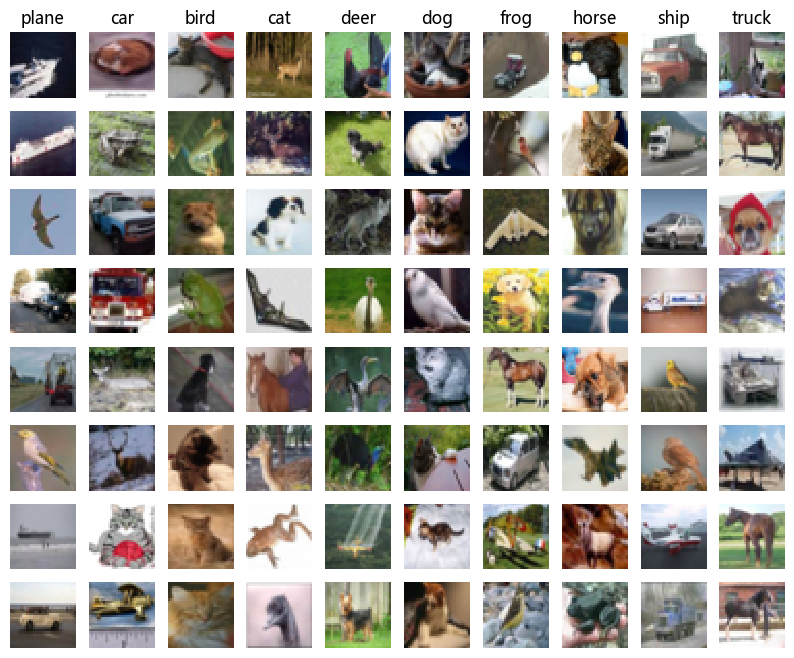

In [41]:
# 通过可视化算法的错误样本来加深对其工作方式的理解是一种重要手段。
# 下面展示当前系统误分类的示例。
# 第一列展示的是被模型标记为“飞机”(plane)，但真实标签却并非“飞机”的图片。

examples_per_class = 8           # 每个类别展示 8 张误分类图
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']  # CIFAR-10 的 10 个类别名

# 遍历每个类别
for cls, cls_name in enumerate(classes):
    # 找出满足“真实标签 ≠ cls 且预测标签 = cls”的测试样本下标
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    # 随机挑 examples_per_class 张图，不重复
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    
    # 依次绘制图片
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes),
                    i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))  # 显示原始图像
        plt.axis('off')                          # 去掉坐标轴
        # 只在第一行写类别名作为标题
        if i == 0:
            plt.title(cls_name)

plt.show()

### 内联问题 1：
请描述你观察到的误分类结果。它们是否合理？

$\color{blue}{\textit{你的答案：}}$


这些误分类是完全合理的，原因如下：

数据本身的局限性：CIFAR-10 图片分辨率仅为 32×32，细节丢失严重，很多类别的关键特征（如猫的尖耳朵、狗的口鼻轮廓）难以被捕捉。

类别间的天然相似性：很多类别在视觉特征上存在重叠，比如：

猫和狗：都是小型四足动物，毛发纹理和姿态高度相似。

青蛙和鸟：绿色皮肤 / 羽毛 + 简单轮廓，低分辨率下难以区分。

模型能力的限制：线性 Softmax 或浅层全连接网络，仅能学习简单的线性特征，无法捕捉复杂的纹理、局部特征和上下文信息，因此容易被颜色、背景等浅层特征误导。



## 在图像特征上训练神经网络
在作业的前面部分，我们已经看到：  
在原始像素上训练两层神经网络，其分类效果优于直接在原始像素上训练的线性分类器。  
而在本 notebook 中，我们又发现：在图像特征上训练的线性分类器，效果比在原始像素上训练的线性分类器更好。

为了完整性，我们还应该在图像特征上训练神经网络。  
这种做法应当能超越之前所有方案：你很容易就能在测试集上获得 **超过 55%** 的分类准确率；  
我们最好的模型能达到约 **60%** 的测试准确率。

In [42]:
# 预处理：去掉之前添加的偏置维度（bias dimension）
# 注意：此代码单元只需执行一次！

print("原始特征维度：", X_train_feats.shape)  # 查看当前形状（最后一列为偏置 1）

# 通过切片去掉最后一列（bias 列）
X_train_feats = X_train_feats[:, :-1]
X_val_feats   = X_val_feats[:, :-1]
X_test_feats  = X_test_feats[:, :-1]

print("去掉偏置后的特征维度：", X_train_feats.shape)

原始特征维度： (49000, 170)
去掉偏置后的特征维度： (49000, 169)


In [75]:
# 从 cs231n 中导入两层全连接网络 TwoLayerNet 以及通用训练器 Solver
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

# 设置网络参数
input_dim   = X_train_feats.shape[1]   # 输入特征维度
hidden_dim  = 500                      # 隐藏层神经元个数
num_classes = 10                       # 输出类别数（CIFAR-10 共 10 类）

# 将训练、验证、测试数据打包成字典，方便 Solver 使用
data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val':   X_val_feats,
    'y_val':   y_val,
    'X_test':  X_test_feats,
    'y_test':  y_test,
}

# 初始化两层神经网络
net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None   # 用于保存训练出的最优模型

################################################################################
# 代办: 在提取的图像特征上训练两层神经网络。你可以像前面章节一样进行交叉验证调参。  #
# 将最终表现最好的模型保存到 best_net 变量中。                                   #
################################################################################

# 设定待搜索的学习率和正则化强度候选值
learning_rates = [1.5e-1, 1.8e-1, 2e-1, 2.2e-1]
regularization_strengths = [1.5e-3, 1.8e-3, 2e-3, 2.2e-3, 2.5e-3, 2.8e-3, 3e-3]

# 用于保存不同超参数组合下的训练/验证结果
results = {}
best_val = -1              # 目前最高的验证准确率
best_net = None            # 对应最高验证准确率的神经网络

# 网格搜索所有超参数组合
for lr in learning_rates:
    for reg in regularization_strengths:
        # 创建两层神经网络
        net = TwoLayerNet(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes)
        
        # 使用Solver训练网络
        solver = Solver(net, data,
                        update_rule='sgd',
                        optim_config={
                            'learning_rate': lr,
                        },
                        lr_decay=0.95,
                        num_epochs=20, 
                        batch_size=256,
                        verbose=False, print_every=500)
        
        # 训练模型
        solver.train()
        
        # 计算训练集和验证集准确率
        y_train_pred = np.argmax(net.loss(data['X_train']), axis=1)
        y_val_pred = np.argmax(net.loss(data['X_val']), axis=1)
        
        train_acc = np.mean(y_train == y_train_pred)
        val_acc = np.mean(y_val == y_val_pred)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_net = net

# 打印调参结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e  reg %e  训练准确率: %f  验证准确率: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('在验证集上取得的最高准确率: %f' % best_val)


lr 1.500000e-01  reg 1.500000e-03  训练准确率: 0.680796  验证准确率: 0.603000
lr 1.500000e-01  reg 1.800000e-03  训练准确率: 0.685184  验证准确率: 0.625000
lr 1.500000e-01  reg 2.000000e-03  训练准确率: 0.675286  验证准确率: 0.606000
lr 1.500000e-01  reg 2.200000e-03  训练准确率: 0.670286  验证准确率: 0.614000
lr 1.500000e-01  reg 2.500000e-03  训练准确率: 0.680735  验证准确率: 0.605000
lr 1.500000e-01  reg 2.800000e-03  训练准确率: 0.674653  验证准确率: 0.608000
lr 1.500000e-01  reg 3.000000e-03  训练准确率: 0.683082  验证准确率: 0.607000
lr 1.800000e-01  reg 1.500000e-03  训练准确率: 0.714408  验证准确率: 0.605000
lr 1.800000e-01  reg 1.800000e-03  训练准确率: 0.713878  验证准确率: 0.611000
lr 1.800000e-01  reg 2.000000e-03  训练准确率: 0.684061  验证准确率: 0.605000
lr 1.800000e-01  reg 2.200000e-03  训练准确率: 0.702327  验证准确率: 0.605000
lr 1.800000e-01  reg 2.500000e-03  训练准确率: 0.700082  验证准确率: 0.612000
lr 1.800000e-01  reg 2.800000e-03  训练准确率: 0.717306  验证准确率: 0.614000
lr 1.800000e-01  reg 3.000000e-03  训练准确率: 0.688796  验证准确率: 0.618000
lr 2.000000e-01  reg 1.500000e-03  训练准确率: 0.7201

In [90]:
# 在测试集上运行你表现最好的神经网络分类器
# 你应该能够获得超过 58% 的准确率；如果仔细调参，甚至可以超过 60%。

# 使用 best_net 计算测试样本属于各类别的得分
y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)  # 取得分最高的类别作为预测结果
test_acc = (y_test_pred == data['y_test']).mean()               # 计算测试集准确率
print(test_acc)                                                 # 打印结果

0.594


In [81]:
# 将表现最佳的两层神经网络模型保存到文件
# 后续可直接加载 best_two_layer_net_features.npy，无需重新训练
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy 已保存。
